<a href="https://colab.research.google.com/github/sonyakuma-droid/EMSC2010-W2-P1/blob/main/EMSC2010_Group_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Bugs, Bush & Biodiviersity

Project week: Week 7

Project title: Water Quality in Australian Rivers

Datasets used (name and source): "Water Quality data base (event mean concetration for TSS, TN and TP) for Australian Rivers." (Source here:
[LINK](https://data.csiro.au/collection/csiro:14442?_st=browse&_str=23&_si=20&browseType=kw&browseValue=Water%20quality))

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Sienna | Seth | Partial| Add note|
| Data steward | Seth | MJ | Yes| Excel file uploaded to Group Forum|
| Analysis / modelling | MJ | Mia | Yes| Let me know if anyone has any trouble with anything I wrote  - happy to make any changes|
| Visualisation / interpretation | Mia | Sonya | Yes/Partial/No| Add note|
| Narrative | Sonya | Sienna | Yes/Partial/No| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

**Introduction**

Changes in land use have an effect on water quality. Different land uses can significantly impact the quantity of nutrients entering into waterways. Increased nutrient run-off, primarily nitrogen (N) and phosphorus (P), from land uses such as for urban and industrial, or agriculture or forestry development can severely degrade water quality (Fletcher et al., 2004). These land-use changes have wide-reaching implications for vegetation, biodiversity and agricultural output. Understanding the contribution of different land uses to nutrient run-off and water quality is the basis for modelling (Cooperative Research Centre for Catchment Hydrology [CRCCH], 2005) which can assist in the setting of current and future priorities for better land and water management practices (Queensland Department of Environment and Heritage Protection, 2018).

**Aim and research question**

This project aims to understand how nutrient delivery to downstream water bodies, specifically concentrations of nitrogen and phosphorus, varies with changes in land use. Accordingly, it asks the following research question:

What is the affect of different land use types on concentrations of nitrogen and phosphorus nutrient run-off into waterways?


**Method**

Data and data analysis

Relevant data were sourced from the Water Quality data base (event mean concetration for TSS, TN and TP) for Australian Rivers (Bartley et al., 2012a).
This database collates water quality data for total suspended sediments (TSS), total nitrogen (TN), and total phosphorus (TP) from runoff events in areas with a single primary land-use. Another key parameter for assessing water quality, the Event Mean Concentration (EMC) represents the average concentration in runoff for a particular pollutant for a particular land-use (CRCCH, 2005, p. 8).

The Event Mean Concentration (EMC) of nitrogen (N) and phosphorus (P), measured in mg/L, was recorded for 13 different land-use classifications. Of these, four were chosen for analysis: namely, Urban/Industry (UI), Forestry,
Grazing Native Pasture (GNP), and Grazing Modified Pasture (GMP). These classifications had sufficient data and were most relevant to existing research and literature (Bartley et al., 2012b). Each of EMC-N and EMC-P has 261 data points which are nearly equally shared across the four land-uses (i.e. n for Forest > Urban/industry). Addtional data cleaning and editing included units standardised to mg/L to enable comparison with exisitng literature, and data separated into sheets by land-use classification and N-EMC and P-EMC data points for optional analysis. Data were saved as an excel .xlxs file.

EMC-N and EMC-P were checked for normality before a log-normal distribution was applied.  

## Group Reflections
**Sienna - Github and Integration**

**Seth - Data Steward**

I found difficulty in attempting to find a suitable dataset that contained both a large number of entries suitable for analysis and relevant to our desired group project for analysis. Many sources provided qualitative data that was less useful for our purposes, and many other datasets were incomplete or lacking in complete or relevant data. I only found two datasets that were feasible for our needs and this one proved the most informative. This role allowed me to be a lot more invested in the approach we took to analysis and I found it to be challenging but engaging.

**MJ - Analysis/Modelling**
I found it challenging yet incredibly interesting to compare the two variables (Nitrogen and Phosphorus) across the two different land uses (Urban and Forest). It helped to be genuinely interested in the dataset we are using for this project, and it gave me more context on the nuances of how land use impacts water quality. It's been particularly rewarding to apply the coding skills and Bayesian analysis techniques learned in class, as well as searching for support online to further the code (as well as using some AI assitance when stuck). I do not yet feel anywhere near fluent in Python but it is a language I am coming to appreciate more and more. I initally did the analysis with on ly 2 landuses and the 2 chemicals, however then decided to add the remaining 2 landuses fromSeth's spread sheet to round out the analysis. This was a bit tricky but was essentially duplicated code with some tweaks.
 (Additional note: For future years of this class, this is some feedback. I found I had to generate all the plots as I went along to ensure everything worked and made sense - this then felt as though I had stepped on Mia's toes and her role as 'visualisation/interpretation'. Indeed, my plots are basic and can be improved upon by Mia I am sure - however it does not feel like these two roles make much sense being seperate. Just a thought).

 **Mia - Visualisation and interpretation**

 My role this week was fairly simple as most visualisation and plotting was required to conduct the modelling and analysis, and so was completed by MJ. I made sure titles and labels were included in plots in the analysis section. I found it difficult to think of other ways to contribute to this role this week. I used AI to generate box plots of the raw data and replicated a difference visualisation model we used in the 'air pressure' example in Friday's practical. I'm unsure if my visualisations provide further insight or bolster interpretation beyond MJ's initial analysis, but I did not want to leave my work space blank. I found my role this week easy and I would be interested in learning more about how to utilise graphs in Python.

In [ ]:
import pymc as pm # Bayesian modelling and posterior analysis
import arviz as az # Used for visualization and diagnostic plotting of Bayesian models
import numpy as np # Used for numerical operations, especially with arrays
import pandas as pd # Used for data manipulation and analysis, especially with DataFrames
import matplotlib.pyplot as plt # Used for creating data visualizations
from scipy import stats # Used for statistical functions
import seaborn as sns # Useful for creating detailed statistical graphs

In [ ]:

df = pd.read_excel("EMC Datasheets.xlsx", sheet_name="Cleaned but Unedited") # Load the cleaned EMC dataset
df.head() # see the first few rows

,Primary Land Use,Nitrogen EMC or mean concentration (ug/l),Nitrogen EMC (mg/L),Phosphorus EMC or mean concentration (ug/l),Phosphorus EMC (mg/l)
0,Forest,2340.5,2.3405,157.50,0.15750
1,Forest,537.6,0.5376,15.90,0.01590
2,Forest,1400.0,1.4000,360.00,0.36000
3,Forest,167.0,0.1670,16.26,0.01626
4,Forest,1450.0,1.4500,80.00,0.08000


In [ ]:
df = df[["Primary Land Use", "Nitrogen EMC (mg/L)", "Phosphorus EMC (mg/l)"]] # Reading only the columns we need

df = df.rename(columns={"Primary Land Use": "land_use", "Nitrogen EMC (mg/L)": "N", "Phosphorus EMC (mg/l)": "P"}) # Renaming columns for cleaner code


In [ ]:
land_uses = ["Forest", "Urban / Industry", "Grazing Modified Pastures", "Grazing Native Pastures"] # Defining land-use categories of interest
df_sub = df[df["land_use"].isin(land_uses)]

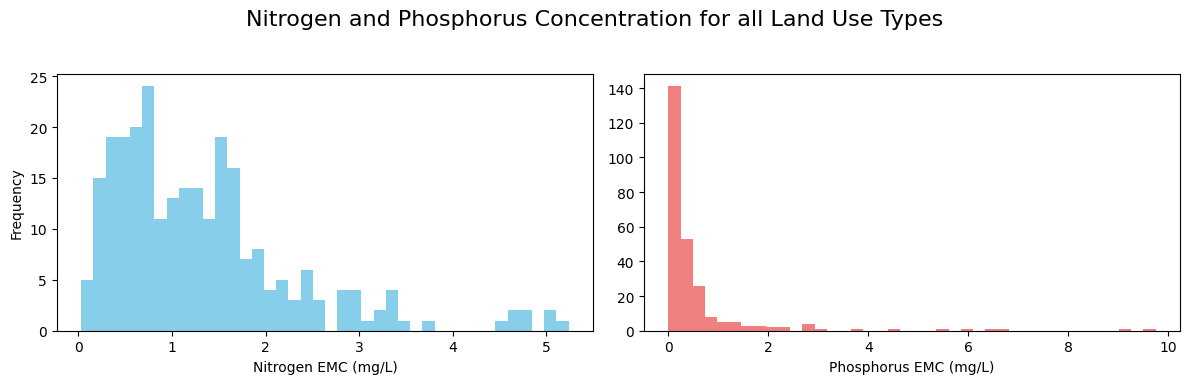

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4)) # Plot histograms to examine skewness and positivity

axes[0].hist(df_sub["N"], bins=40, color='skyblue')
axes[0].set_xlabel("Nitrogen EMC (mg/L)")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_sub["P"], bins=40, color='lightcoral')
axes[1].set_xlabel("Phosphorus EMC (mg/L)")

fig.suptitle('Nitrogen and Phosphorus Concentration for all Land Use Types', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) #Adjust layout to prevent title overlap
plt.show()

In [ ]:
#The distributions are both strictly positive and strongly right‑skewed, meaning a Log‑Normal distribution is better than a normal distribution

In [ ]:
# Handle non-finite values and zeros for all datasets, essential for the log-normal model which requires strictly positive values.
def clean_data(data):
    # Filter out NaN values first
    cleaned_data = data[~np.isnan(data)]
    # Replace zero values with a small epsilon to avoid issues with log-normal distribution
    epsilon = 1e-9 # A very small positive number
    cleaned_data[cleaned_data == 0] = epsilon
    return cleaned_data

def fit_lognormal_model(data, label): #Fits a Bayesian Log-Normal model to nutrient concentration data.

    #This function assumes:
    #- Concentrations are strictly positive.
    #- The natural logarithm of the concentration is Normally distributed.

    #Parameters:

    data : array-like
        #The observed nutrient concentration data (e.g., Nitrogen or Phosphorus).
        #Must contain only positive values.
    label : str
        #A string label to identify the data/model in plots (e.g., "Nitrogen - Forest").

    #Returns:

    az.InferenceData
        #An InferenceData object containing posterior samples of the model parameters,
        #including the log-mean (mu) and log-scale (sigma).

    with pm.Model() as model:

      # Prior for the log-mean concentration
      mu = pm.Normal("mu", mu=np.log(1.0), sigma=1.5) #We centre this around log(1 mg/L) with large uncertainty

      # Prior for log-scale spread (must be positive)
      sigma = pm.HalfNormal("sigma", sigma=1.0) #no negative distribution means we use 'halfnormal'

      # Log-Normal likelihood for observed concentrations
      obs = pm.LogNormal("obs", mu=mu, sigma=sigma, observed=data)

      # 20,000 samples from the posterior
      trace = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=True, target_accept=0.99) # Increased target_accept

  # Plot posterior for the log-mean #plots will be shown below under the N & P data callout code
    az.plot_posterior(trace, var_names=["mu"])
    plt.title(f"Posterior for log-mean concentration ({label})")
    plt.show()

    return trace

# **Examining the Nitrogen data (four landuses)**

Output()

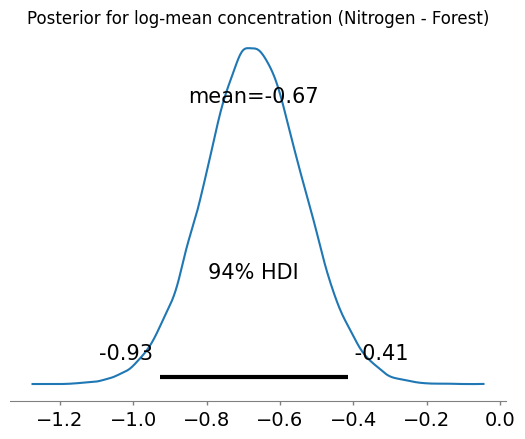

Output()

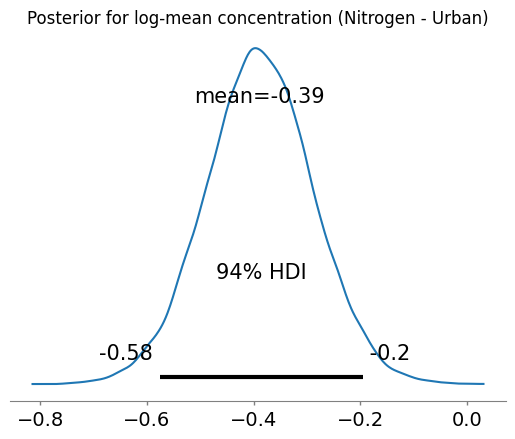

Output()

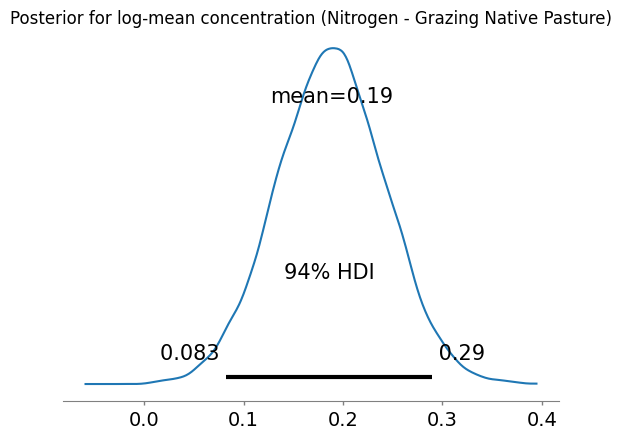

Output()

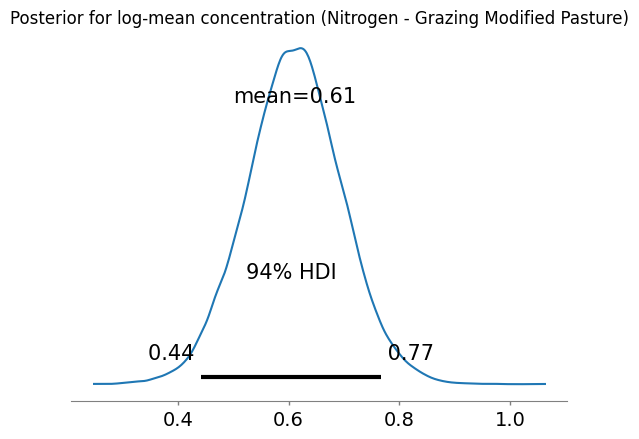

In [ ]:
# Extract Nitrogen data for all four land uses
N_forest = df_sub[df_sub["land_use"] == "Forest"]["N"].values
N_urban  = df_sub[df_sub["land_use"] == "Urban / Industry"]["N"].values
N_grazing_native = df_sub[df_sub["land_use"] == "Grazing Native Pastures"]["N"].values
N_grazing_modified = df_sub[df_sub["land_use"] == "Grazing Modified Pastures"]["N"].values

# Fit models for Nitrogen across all four land uses
trace_N_forest = fit_lognormal_model(N_forest, "Nitrogen - Forest")
trace_N_urban  = fit_lognormal_model(N_urban,  "Nitrogen - Urban")
trace_N_grazing_native = fit_lognormal_model(N_grazing_native, "Nitrogen - Grazing Native Pasture")
trace_N_grazing_modified = fit_lognormal_model(N_grazing_modified, "Nitrogen - Grazing Modified Pasture")

# Extract posterior samples for Nitrogen
mu_forest = trace_N_forest.posterior["mu"].values.flatten()
mu_urban  = trace_N_urban.posterior["mu"].values.flatten()
mu_grazing_native = trace_N_grazing_native.posterior["mu"].values.flatten()
mu_grazing_modified = trace_N_grazing_modified.posterior["mu"].values.flatten()

# The combined plot later will provide the overall comparison.

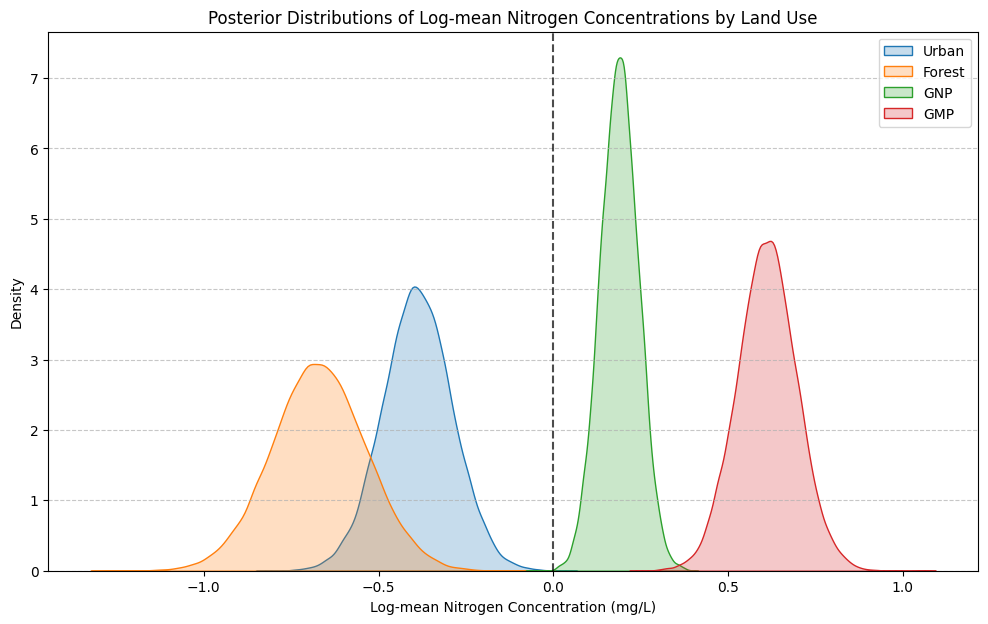

In [ ]:
#Visualising comparison of Log-mean Nitrogen Posterior Distributions by Land Use

plt.figure(figsize=(12, 7))
sns.kdeplot(mu_urban, label='Urban', fill=True)
sns.kdeplot(mu_forest, label='Forest', fill=True)
sns.kdeplot(mu_grazing_native, label='GNP', fill=True)
sns.kdeplot(mu_grazing_modified, label='GMP', fill=True)

plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Posterior Distributions of Log-mean Nitrogen Concentrations by Land Use')
plt.xlabel('Log-mean Nitrogen Concentration (mg/L)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Examining the Phosphorus data (four land uses)**

---



Output()

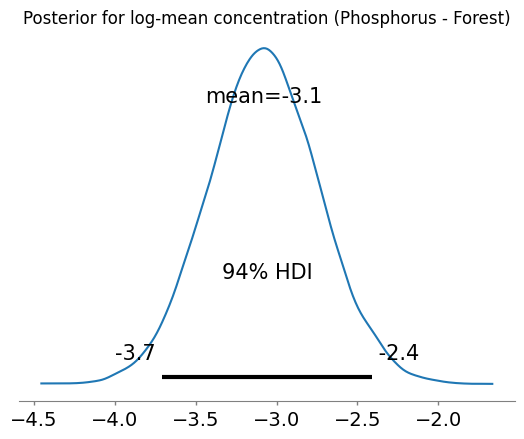

Output()

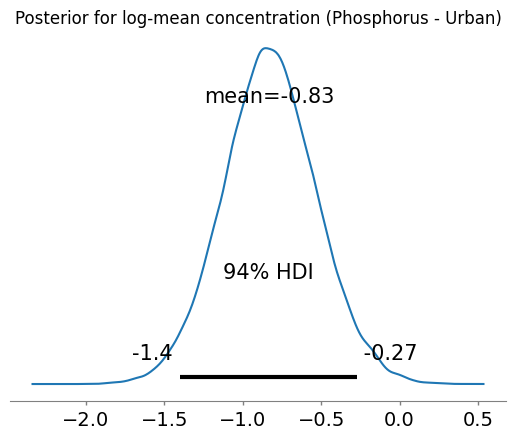

Output()

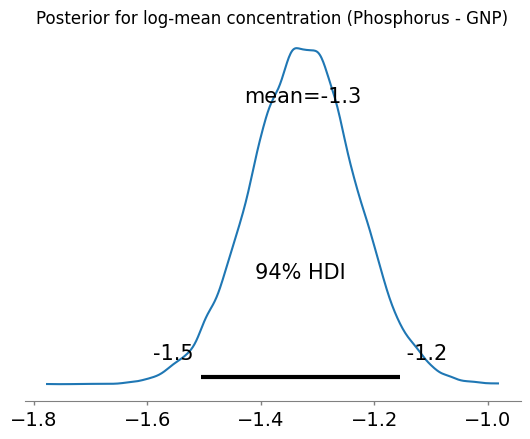

Output()

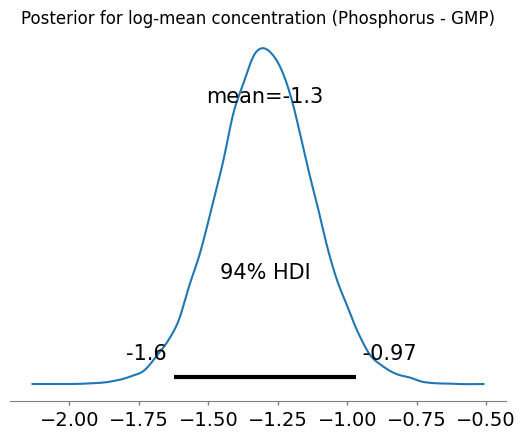

In [ ]:
# Extract Phosphorus data for all four land uses
P_forest = df_sub[df_sub["land_use"] == "Forest"]["P"].values
P_urban  = df_sub[df_sub["land_use"] == "Urban / Industry"]["P"].values
P_grazing_native = df_sub[df_sub["land_use"] == "Grazing Native Pastures"]["P"].values
P_grazing_modified = df_sub[df_sub["land_use"] == "Grazing Modified Pastures"]["P"].values

P_forest = clean_data(P_forest)
P_urban = clean_data(P_urban)
P_grazing_native = clean_data(P_grazing_native)
P_grazing_modified = clean_data(P_grazing_modified)

# Fit models for Phosphorus across all four land uses
trace_P_forest = fit_lognormal_model(P_forest, "Phosphorus - Forest")
trace_P_urban  = fit_lognormal_model(P_urban,  "Phosphorus - Urban")
trace_P_grazing_native = fit_lognormal_model(P_grazing_native, "Phosphorus - GNP")
trace_P_grazing_modified = fit_lognormal_model(P_grazing_modified, "Phosphorus - GMP")

# Extract posterior samples for Phosphorus
mu_forest_P = trace_P_forest.posterior["mu"].values.flatten()
mu_urban_P  = trace_P_urban.posterior["mu"].values.flatten()
mu_grazing_native_P = trace_P_grazing_native.posterior["mu"].values.flatten()
mu_grazing_modified_P = trace_P_grazing_modified.posterior["mu"].values.flatten()

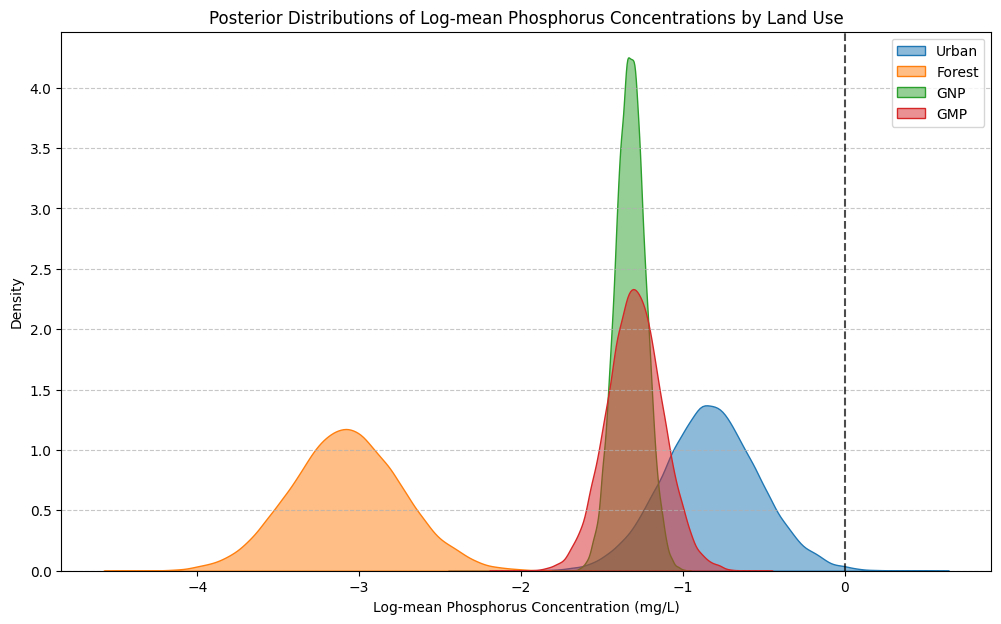

In [ ]:
#Visualising comparison of Log-mean Phosphorus Posterior Distributions by Land Use

plt.figure(figsize=(12, 7))
sns.kdeplot(mu_urban_P, label='Urban', fill=True, alpha=0.5)
sns.kdeplot(mu_forest_P, label='Forest', fill=True, alpha=0.5)
sns.kdeplot(mu_grazing_native_P, label='GNP', fill=True, alpha=0.5)
sns.kdeplot(mu_grazing_modified_P, label='GMP', fill=True, alpha=0.5)

plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Posterior Distributions of Log-mean Phosphorus Concentrations by Land Use')
plt.xlabel('Log-mean Phosphorus Concentration (mg/L)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This code visualizes the posterior distributions of log-mean phosphorus concentrations across different land uses (Urban, Forest, Grazing Native Pasture, and Grazing Modified Pasture). Each `sns.kdeplot` line draws the estimated probability density function for the log-mean phosphorus concentration for a specific land use, allowing for a direct comparison of their estimated average levels and uncertainties. The vertical line at 0 represents a log-mean concentration of 1 mg/L, helping to anchor the comparison.

# **Combined Posterior Distributions of Log-mean Concentrations for Nitrogen and Phosphorus across Urban and Forest Land Uses**

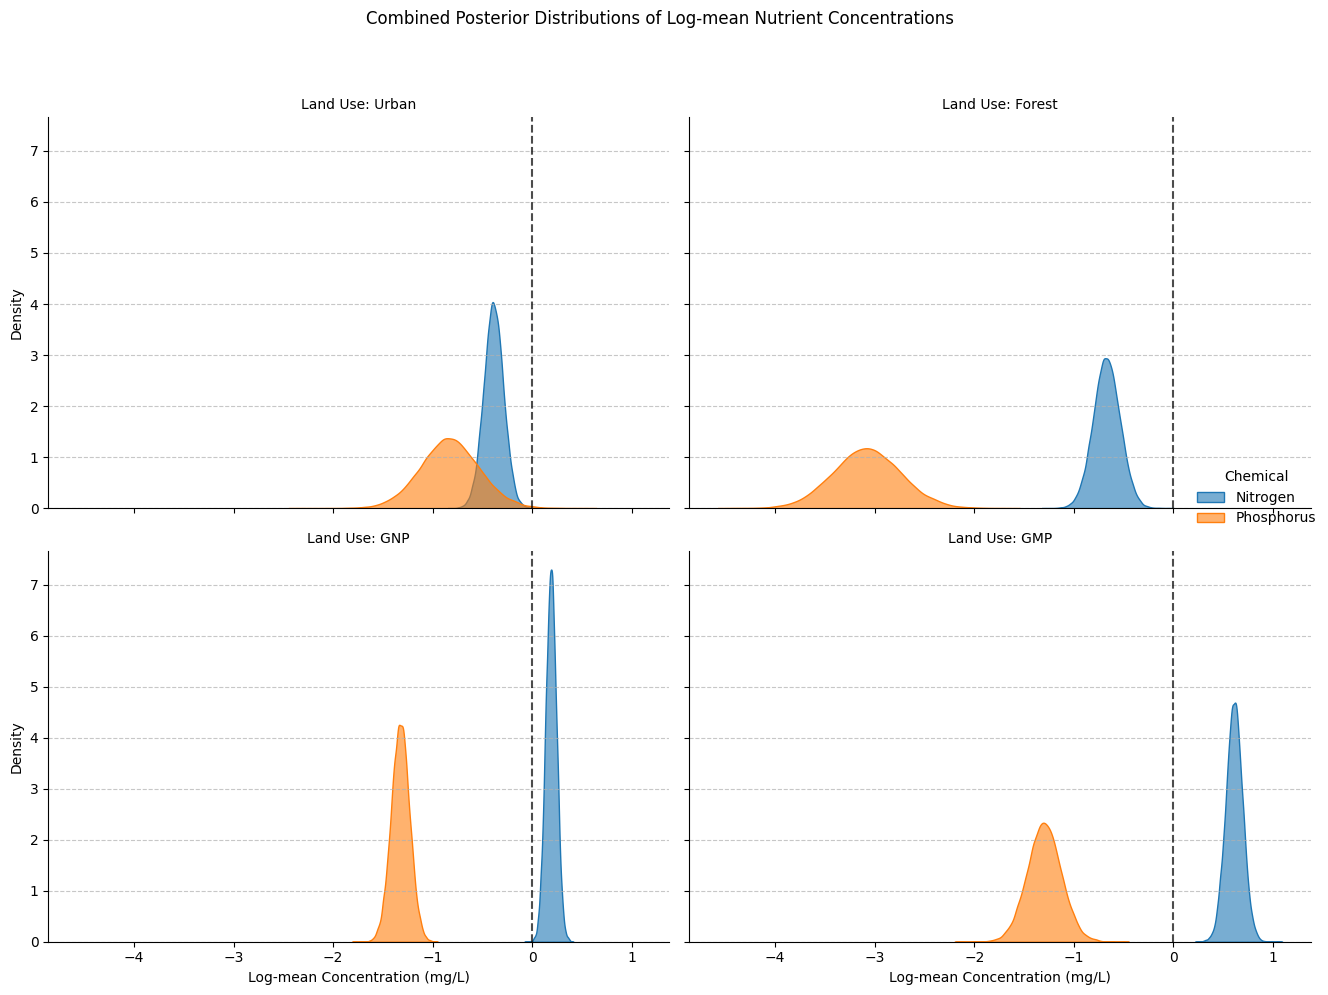

In [ ]:
# Create a DataFrame for Nitrogen posterior samples
df_N_posteriors = pd.DataFrame({
    'Log_Mean_Concentration': np.concatenate([mu_urban, mu_forest, mu_grazing_native, mu_grazing_modified]),
    'Land_Use': ['Urban'] * len(mu_urban) + ['Forest'] * len(mu_forest) + ['GNP'] * len(mu_grazing_native) + ['GMP'] * len(mu_grazing_modified),
    'Chemical': 'Nitrogen'})

# Create a DataFrame for Phosphorus posterior samples
df_P_posteriors = pd.DataFrame({
    'Log_Mean_Concentration': np.concatenate([mu_urban_P, mu_forest_P, mu_grazing_native_P, mu_grazing_modified_P]),
    'Land_Use': ['Urban'] * len(mu_urban_P) + ['Forest'] * len(mu_forest_P) + ['GNP'] * len(mu_grazing_native_P) + ['GMP'] * len(mu_grazing_modified_P),
    'Chemical': 'Phosphorus'})

# Combine both DataFrames
df_combined_posteriors = pd.concat([df_N_posteriors, df_P_posteriors])

# Create a FacetGrid for land use, and use hue for chemical
g = sns.FacetGrid(df_combined_posteriors, col='Land_Use', hue='Chemical', col_wrap=2, height=5, aspect=1.2)
g.map(sns.kdeplot, 'Log_Mean_Concentration', fill=True, alpha=0.6)
g.add_legend(title='Chemical')

# Add a vertical line at 0 (log(1 mg/L))
for ax in g.axes.flat:
    ax.axvline(0, color='black', linestyle='--', alpha=0.7, label='Log(1 mg/L)')
    ax.set_xlabel('Log-mean Concentration (mg/L)')
    ax.set_ylabel('Density')
    ax.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better readability

g.set_titles('Land Use: {col_name}')
plt.suptitle('Combined Posterior Distributions of Log-mean Nutrient Concentrations', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

The above combined visualization extends our understanding of nutrient concentrations across all four land uses for both Nitrogen and Phosphorus.

*   **Urban/Industry vs. Forest:** For both Nitrogen and Phosphorus, the posterior distributions for 'Urban / Industry' land use are significantly shifted to the right (higher log-mean concentrations) compared to 'Forest' land use, indicating that urban areas are associated with substantially higher nutrient levels.
*   **Grazing Land Uses (GNP & GMP):**
    *   **Nitrogen:** Both 'Grazing Native Pastures' (GNP) and 'Grazing Modified Pastures' (GMP) show higher log-mean Nitrogen concentrations than 'Forest' areas. 'Grazing Modified Pastures' often overlap or are very close to 'Urban / Industry' concentrations, suggesting a significant impact from modified pasture practices on Nitrogen levels. 'GNP' generally sits between 'Forest' and 'GMP'/'Urban'.
    *   **Phosphorus:** Similar to Nitrogen, 'GNP' and 'GMP' exhibit higher log-mean Phosphorus concentrations than 'Forest'. 'GMP' tends to have higher Phosphorus levels than 'GNP', though both are generally lower than 'Urban / Industry' concentrations, which show the highest and broadest distributions.
*   **Nitrogen vs. Phosphorus:** The overall pattern of land-use impact is consistent across both nutrients: Urban/Industry > Grazing (especially GMP) > Forest. However, the magnitude of the difference can vary, with Phosphorus often showing a more pronounced separation between the lowest ('Forest') and highest ('Urban / Industry') concentrations.
*   **Overall:** This plot strongly suggests a clear hierarchy of human impact on water quality: 'Urban / Industry' land use is associated with the highest average concentrations of both Nitrogen and Phosphorus, followed by 'Grazing Modified Pastures', then 'Grazing Native Pastures', and finally 'Forest' areas, which exhibit the lowest nutrient levels. The models quantify the uncertainty around these differences, with narrower distributions for land uses with more data (e.g., Forest) and wider distributions for those with less (e.g., Urban).

# Explanation for Observed Concentration Differences Across All Land Uses


The observed log-mean concentrations of both Nitrogen (N) and Phosphorus (P) demonstrate a clear gradient linked to land use, primarily driven by anthropogenic impacts and natural ecosystem functions:

*   **Urban / Industry (Highest Concentrations):**
    *   **Sources:** These areas are major contributors of N and P due to stormwater runoff (carrying pollutants, pet waste, and fertilizers from lawns), discharge of treated and untreated wastewater, and industrial effluents. High population density and impervious surfaces exacerbate runoff, preventing natural filtration.
    *   **Magnitude:** This land use consistently exhibits the highest concentrations for both nutrients, especially Phosphorus, which can be highly concentrated in urban byproducts and prone to transport through erosion.

*   **Grazing Modified Pastures (High Concentrations):**
    *   **Sources:** Similar to urban areas, but with a focus on agricultural practices. Fertilizers (containing N and P) applied to pastures, animal waste, and soil disturbance leading to erosion contribute significantly. The 'modified' aspect implies intensive management, which often includes higher fertilizer use and altered natural drainage.
    *   **Magnitude:** Concentrations are typically higher than natural grazing or forests, often approaching or overlapping with urban levels, particularly for Nitrogen.

*   **Grazing Native Pastures (Moderate Concentrations):**
    *   **Sources:** While still impacted by livestock (animal waste) and some level of soil disturbance, 'native' pastures generally imply less intensive management, lower fertilizer input, and potentially better soil structure compared to modified pastures. Runoff containing nutrients from these sources is still present but often at lower levels.
    *   **Magnitude:** Concentrations are typically intermediate, falling between those of modified grazing/urban areas and natural forests.

*   **Forest (Lowest Concentrations):**
    *   **Sources:** Minimal anthropogenic inputs. Nutrient cycling in these systems is largely natural.
    *   **Natural Filtering:** Intact forest ecosystems, with their dense vegetation, healthy soil structures, and extensive root systems, act as highly efficient natural filters. They retain and cycle nutrients effectively, preventing their excessive leaching or runoff into waterways.
    *   **Magnitude:** Consistently show the lowest concentrations of both N and P, highlighting their role in maintaining high water quality.

**Key Factors Influencing Differences:**

1.  **Anthropogenic Inputs:** Directly correlated with human activity (urbanization, agriculture).
2.  **Natural Filtration Capacity:** Diminished in developed and agricultural landscapes compared to forests.
3.  **Nutrient Cycling:** Disrupted by land use changes, leading to greater export of nutrients into aquatic systems.
4.  **Phosphorus Specifics:** The more pronounced differences often observed for Phosphorus are due to its strong binding to soil particles, making it highly susceptible to transport via erosion (common in disturbed landscapes) and its prevalence in man-made products.

# Visualisation - Mia Jaggers

Much of the visualisation and interpretation was conducted by MJ as part of her analysis. I ensured all plots and graphs were tidy and had titles and axis labels.

I asked Gemini how else I could visualise the data and analysis, and it suggested generating box plots of the raw data distributions between Nitrogen and Phosphorus. The below box plots show the distribution of observed Nitrogen and Phosphorus concentrations across the four land use types.

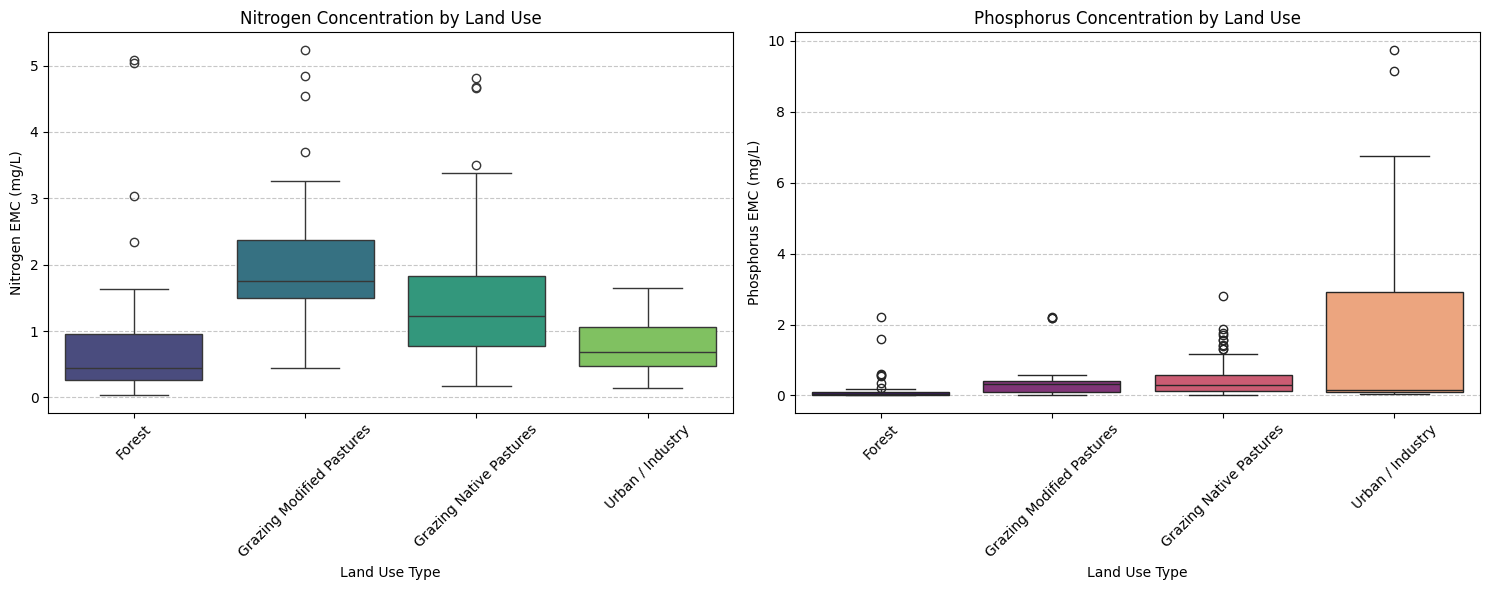

In [ ]:
# Create subplots for Nitrogen and Phosphorus box plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot for Nitrogen concentrations by land use
sns.boxplot(x='land_use', y='N', data=df_sub, ax=axes[0], hue='land_use', palette='viridis', legend=False)
axes[0].set_title('Nitrogen Concentration by Land Use')
axes[0].set_xlabel('Land Use Type')
axes[0].set_ylabel('Nitrogen EMC (mg/L)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Box plot for Phosphorus concentrations by land use
sns.boxplot(x='land_use', y='P', data=df_sub, ax=axes[1], hue='land_use', palette='magma', legend=False)
axes[1].set_title('Phosphorus Concentration by Land Use')
axes[1].set_xlabel('Land Use Type')
axes[1].set_ylabel('Phosphorus EMC (mg/L)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Differences in N and P concentrations for Forest and Urban land use types**

I wanted to plot the concentration differences between Forest and Urban land use types because they had the most pronounced differences out of all land use types.

- I used code from last week's Notebook to conduct the differential analysis and plot historgrams of the difference in Nitrogen and Phosphorus concentrations between Urban and Forest land use types.
- I then asked Gemini to plot my histograms to appear side-by-side.

In [ ]:
#Extract the prosterior samples as a numpy array

#forest and urban Phosphorus
mu_forest_P = trace_P_forest.posterior["mu"].values.flatten()
mu_urban_P  = trace_P_urban.posterior["mu"].values.flatten()

#forest and urban Nitrogen
mu_forest = trace_N_forest.posterior["mu"].values.flatten()
mu_urban  = trace_N_urban.posterior["mu"].values.flatten()

Text(0.5, 1.0, 'Difference in Forest-Urban Land Use Phosphorus Concentration')

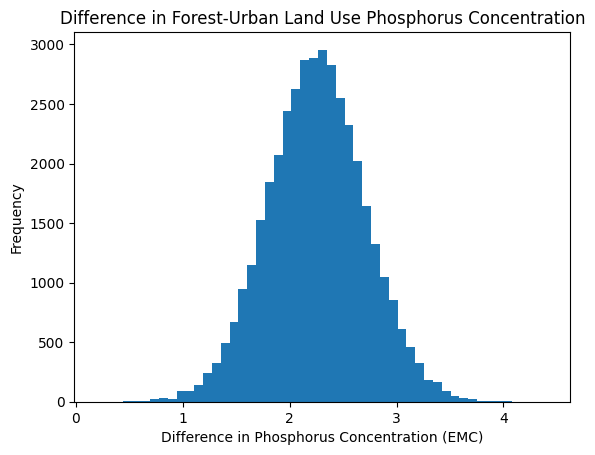

In [ ]:
# subtracting means to find Phosphorus difference

mu_diff1 = mu_urban_P - mu_forest_P

#plotting forest-urban phosphorus difference
plt.hist(mu_diff1, bins=51);
plt.xlabel('Difference in Phosphorus Concentration (EMC)')
plt.ylabel('Frequency')
plt.title('Difference in Forest-Urban Land Use Phosphorus Concentration')

Text(0.5, 1.0, 'Difference in Forest-Urban Land Use Nitrogen Concentration')

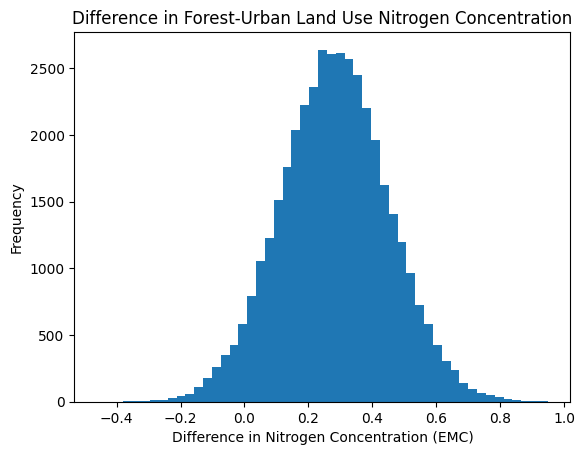

In [ ]:
# subtracting means to find Nitrogen difference

mu_diff2 = mu_urban - mu_forest

#plotting forest-urban Nitrogen difference
plt.hist(mu_diff2, bins=51);
plt.xlabel('Difference in Nitrogen Concentration (EMC)')
plt.ylabel('Frequency')
plt.title('Difference in Forest-Urban Land Use Nitrogen Concentration')

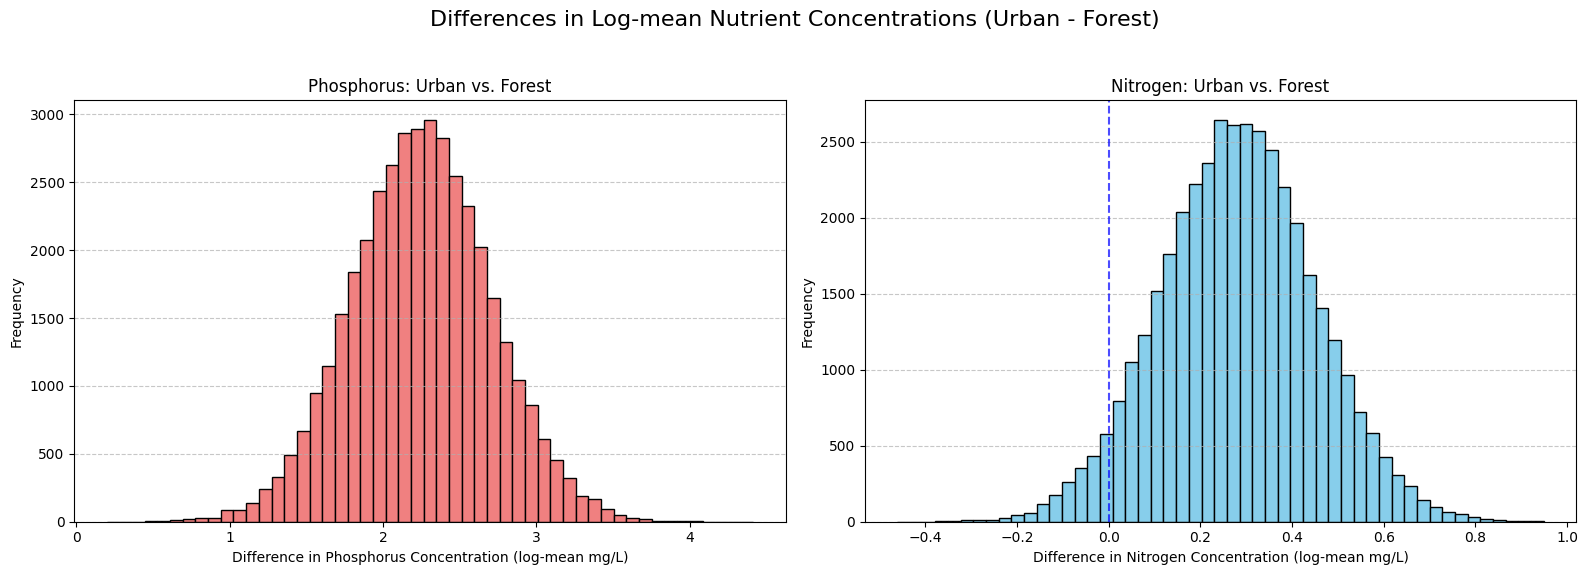

In [ ]:
## plotting the differences in Nitrogen and Phosphorus concentration by Urban and Forest land use

# Calculate differences in log-mean concentrations
mu_diff1 = mu_urban_P - mu_forest_P  # Phosphorus: Urban vs Forest
mu_diff2 = mu_urban - mu_forest      # Nitrogen: Urban vs Forest

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Phosphorus difference
axes[0].hist(mu_diff1, bins=51, color='lightcoral', edgecolor='black')
axes[0].set_xlabel('Difference in Phosphorus Concentration (log-mean mg/L)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Phosphorus: Urban vs. Forest')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Nitrogen difference
axes[1].hist(mu_diff2, bins=51, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Difference in Nitrogen Concentration (log-mean mg/L)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Nitrogen: Urban vs. Forest')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].axvline(0, color='blue', linestyle='--', alpha=0.7) #added a guideline for 0

plt.suptitle('Differences in Log-mean Nutrient Concentrations (Urban - Forest)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

There is a more significant difference in Phosphorus concentration for Urban and Forest land uses than for Nitrogen concentration, as seen above.

**Interpretation:** Conducted by MJ in her above section.

**References**

Bartley, R., Speirs, W. J., Ellis, T. M., & Waters, D.K. (2012a). A review of sediment and nutrient concentration data from Australia for use in catchment water quality models. *Marine Pollution Bulletin, 65*, 101-106. https://doi.org/10.1016/j.marpolbul.2011.08.009

Bartley, R., Speirs, W., Ellis, T., & Waters, D. (2012b). Water Quality data base (event mean concetration for TSS, TN and TP) for Australian Rivers. v1. CSIRO. Data Collection. https://doi.org/10.4225/08/55C9AD3BA8649

Cooperative Research Centre for Catchment Hydrology (2004). *Water quality models - sediments and nutrients* (Report No. 2). https://toolkit.ewater.org.au/tools/ModelChoice/MC-2.pdf

Fletcher, T., Duncan, H., Poelsma, P., & Lloyd, S. (2004). *Stormwater flow and quality, and the effectiveness of non-proprietary treatment measures - a review and gap analysis* (Report No. 04/8). https://www.ewater.org.au/archive/crcch/overview/archive/pubs/pdfs/technical200408.pdf

Queensland Department of Environment and Heritage Protection. (2018). *Sustainable pollutant loads for target setting*. Healthy Land and Water. https://environment.qld.gov.au/__data/assets/pdf_file/0027/89136/sustainable-loads-modelling-seq-catchments.pdf

